## Bias corrrecting and downscaling climate model data in Python ###
> In this tutorial we learn how to apply the ISIMIP bias correction and statistical downscaling module to output from a CMIP6 DAMIP model (CanESM5)
>
> DAMIP (The Detection and Attribution Model Intercomparison Project) is a part of the Coupled Model Intercomparison Project phase 6 (CMIP6), a coordinated international modelling effort to better understand past, present and future climate. DAMIP is the component of CMIP6 dealing with understanding the individual contributions of various external factors to past and future changes in global and regional climate.
>
> ISMIP (The Inter-Sectoral Impact Model Intercomparison Project) is a framework for consistently projecting the impacts of climate change across affected sectors and spatial scales developed by an international network of climate-impact modellers. ISIMIP develops and provides climate and socioeconomic forcing datasets for cross-sectorally consistent climate impact modeling and curates related model output data
>
>- Objectives
>    - Plot raw DAMIP model output against observations
>    - Bias correct model data to observations 
>    - Downscale coarse model data to match higher resolution observations 
>- Data Inputs
>    - DAMIP historical tas (2 degree lat-lon)
>    - DAMIP historical-natural tas (2 degree lat-lon)
>    - BR-DWGD tas (0.5 degree lat-lon)
>- Data Outputs
>    - Bias corrected hisorical tas (0.5 degree lat-lon)
>    - Bias corrected historical-natural tas (0.5 degree lat-lon)
>- Outcomes
>    - Understand the importance of bias correction and downscaling in climate health attribution

#### 0. Imports

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import xesmf as xe
import bias_correction_functions as bcf
import downscaling_functions as dsf
import analysis_functions as af
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

#### 1. Load data 

In [2]:
# # Add google drive links
# obs_link = "https://drive.google.com/file/d/1N6BLZoHrc_IgtdglfouxEfV1TgzUZcr4/view?usp=sharing"
# hist_nat_link = "https://drive.google.com/file/d/1UXqzw3kBfKrbMIPJhfDexpugeG_rFO0l/view?usp=sharing"
# hist_link = "https://drive.google.com/file/d/1Ki1a-epQbspIdqsl5HhdQ2ilVBdcQRN5/view?usp=sharing"

# gdown.download(
#     obs_link,
#     "obs.nc",
#     quiet=False
# )

# gdown.download(
#     hist_nat_link,
#     "hist_nat.nc",
#     quiet=False
# )

# gdown.download(
#     hist_link,
#     "hist.nc",
#     quiet=False
# )

In [3]:
obs = xr.open_dataarray("obs_05x05_2000_2018_padded_interp_for_tutorial.nc")
hist = xr.open_dataset("tas_CanESM5_historical_r1i1p1f1_v20190429_2000-2018.nc") # Gloabl -> could crop and save a version that is just Brazil

#### 2. Landmask and plot the mean of the observations to check that they look correct and compare resolution with the model

In [4]:
landmask = xr.open_dataarray('brazil_mask_01x01.nc')
mask_05x05 = landmask.coarsen(lat=5, lon=5, boundary='trim').mean()

In [5]:
obs_masked = obs.isel(lat=slice(1,83)).isel(lon=slice(1,83))
obs_masked = obs_masked.assign_coords(lat=mask_05x05.lat, lon=mask_05x05.lon)
obs_masked = obs_masked.where(~np.isnan(mask_05x05))

In [9]:
shapefile = gpd.read_file("RG2017_rgi_20180911/RG2017_rgi.shp")

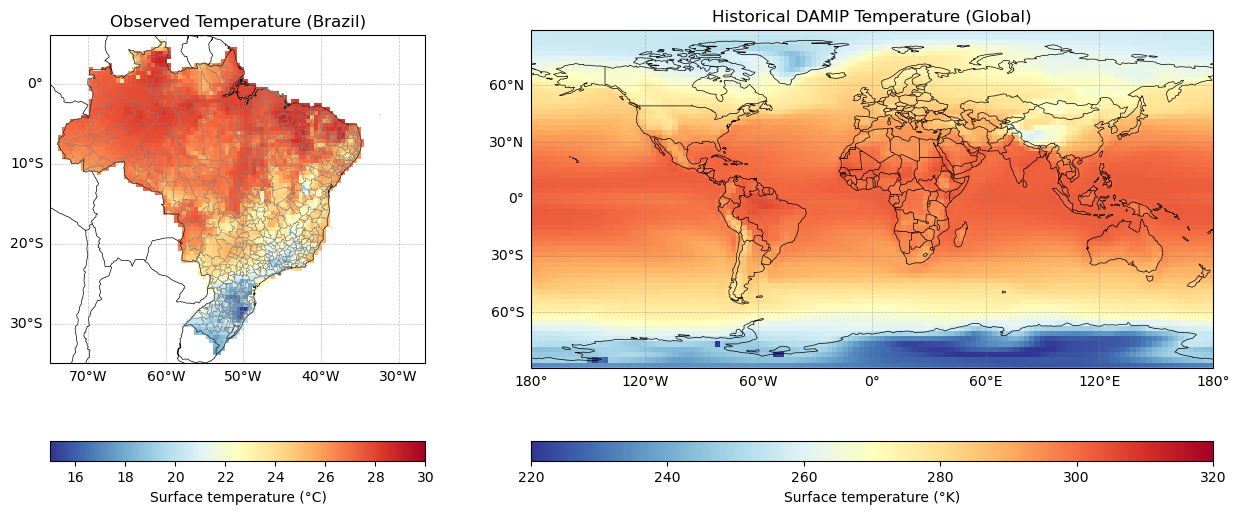

In [ ]:
fig = plt.figure(figsize=(15, 6))
gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 0.05], width_ratios=[0.55, 1], hspace=0.2, wspace=0.2)

ax1 = fig.add_subplot(gs[0,0], projection=ccrs.PlateCarree())
im1 = obs_masked.mean(dim='time').plot(ax=ax1, cmap='RdYlBu_r', vmin=15, vmax=30, add_colorbar=False, transform=ccrs.PlateCarree(), zorder=1)
# Add shapefile boundaries 
shapefile.plot(ax=ax1, facecolor='none', edgecolor='grey', linewidth=0.2, transform=ccrs.PlateCarree(), zorder=2)
# Add features
ax1.add_feature(cfeature.BORDERS, linewidth=0.5)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax1.set_title("Observed Temperature (Brazil)")
# Add gridlines
gl = ax1.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax2 = fig.add_subplot(gs[0,1], projection=ccrs.PlateCarree())
im2 = hist.tas.mean(dim='time').plot(ax=ax2, cmap='RdYlBu_r', vmin=220, vmax=320, add_colorbar=False, transform=ccrs.PlateCarree())
# Add features
ax2.add_feature(cfeature.BORDERS, linewidth=0.5)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax2.set_title("Historical DAMIP Temperature (Global)")
# Add gridlines
gl = ax2.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cax1 = fig.add_subplot(gs[1, 0])
cbar1 = fig.colorbar(im1, cax=cax1, orientation='horizontal')
cbar1.set_label("Surface temperature (°C)")

cax2 = fig.add_subplot(gs[1, 1])
cbar2 = fig.colorbar(im2, cax=cax2, orientation='horizontal')
cbar2.set_label("Surface temperature (°K)")

#### 3. Process model data and regrid obs to model grid

In [18]:
hist_processed = af.process_model_data(hist.tas, obs)

Longitudes in 'lon' shifted to [-180, 180] range.


In [19]:
obs_processed = af.regrid_obs_to_model(obs, hist_processed)

#### 4. Plot processed model data with obs to show model bias 

In [29]:
# Mask for plotting
mask_2x2 = landmask.coarsen(lat=20, lon=20, boundary='trim').mean()
hist_masked = hist_processed.isel(lat=slice(1,21)).isel(lon=slice(1,21))
hist_masked = hist_masked.assign_coords(lat=mask_2x2.lat, lon=mask_2x2.lon)
hist_masked = hist_masked.where(~np.isnan(mask_2x2))

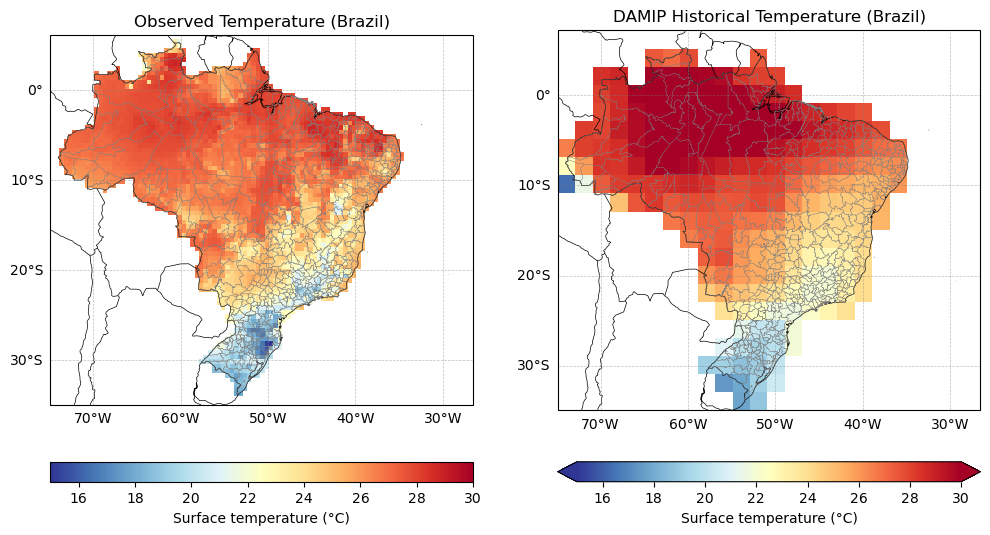

In [30]:
fig = plt.figure(figsize=(12, 6))
gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 0.05], hspace=0.2, wspace=0.2)

ax1 = fig.add_subplot(gs[0,0], projection=ccrs.PlateCarree())
im1 = obs_masked.mean(dim='time').plot(ax=ax1, cmap='RdYlBu_r', vmin=15, vmax=30, add_colorbar=False, transform=ccrs.PlateCarree(), zorder=1)
# Add shapefile boundaries 
shapefile.plot(ax=ax1, facecolor='none', edgecolor='grey', linewidth=0.2, transform=ccrs.PlateCarree(), zorder=2)
# Add features
ax1.add_feature(cfeature.BORDERS, linewidth=0.5)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax1.set_title("Observed Temperature (Brazil)")
# Add gridlines
gl = ax1.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax2 = fig.add_subplot(gs[0,1], projection=ccrs.PlateCarree())
im2 = hist_masked.mean(dim='time').plot(ax=ax2, cmap='RdYlBu_r', vmin=15, vmax=30, add_colorbar=False, transform=ccrs.PlateCarree(), zorder=1)
# Add shapefile boundaries 
shapefile.plot(ax=ax2, facecolor='none', edgecolor='grey', linewidth=0.2, transform=ccrs.PlateCarree(), zorder=2)
# Add features
ax2.add_feature(cfeature.BORDERS, linewidth=0.5)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax2.set_title("DAMIP Historical Temperature (Brazil)")
# Add gridlines
gl = ax2.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cax1 = fig.add_subplot(gs[1, 0])
cbar1 = fig.colorbar(im1, cax=cax1, orientation='horizontal')
cbar1.set_label("Surface temperature (°C)")

cax2 = fig.add_subplot(gs[1, 1])
cbar2 = fig.colorbar(im2, cax=cax2, orientation='horizontal', extend='both')
cbar2.set_label("Surface temperature (°C)")

#### 5. Run bias correction

In [31]:
# Replace nan with zeros
obs_processed = obs_processed.fillna(0)

In [32]:
# Extract arrays as the bias correction function is designed to work with Numpy arrays. 
# Xarray has other metadata attached that will get in the way of the bias correction.
# The function is designed to work with multiple variables, so we pass in lists of arrays even though we only have one variable.

obs_arrays = [obs_processed.values]
train_arrays = [hist_processed.values]
apply_arrays = [hist_processed.values]

# Compute time metadata to pass into bias correction function
years = {
    'obs_hist': obs_processed.time.dt.year.values,
    'sim_hist': hist_processed.time.dt.year.values, 
    'sim_fut': hist_processed.time.dt.year.values
}
days = {
    'obs_hist': obs_processed.time.dt.dayofyear.values,
    'sim_hist': hist_processed.time.dt.dayofyear.values,
    'sim_fut': hist_processed.time.dt.dayofyear.values
}
month_numbers = {
    'obs_hist': obs_processed.time.dt.month.values,
    'sim_hist': hist_processed.time.dt.month.values,
    'sim_fut': hist_processed.time.dt.month.values
}

# Call the bias correction
bias_corrected = bcf.main(
    obs_arrays, train_arrays, apply_arrays,
    variable=['tas'],
    years=years, days=days, month_numbers=month_numbers,
    distribution=['normal'],
    trend_preservation=["additive"],
    detrend=[True],
    halfwin_upper_bound_climatology=[0]
)

adjusting at locations in 23x23 ...


/Users/al18709/Documents/coding_tutorials/attribution_tutorial/utility_functions.py:1572: UserWarning: found fewer then 2 different values in x: returning None
  warnings.warn(msg)
/Users/al18709/Documents/coding_tutorials/attribution_tutorial/bias_correction_functions.py:244: UserWarning: unable to do parametric quantile mapping: doing non-parametric quantile mapping instead
  if spsdotwhat is not None: warnings.warn(msg)


bias adjustment completed. Returning 529 locations of data.


In [33]:
# Reconstruct the full spatial array from bias_corrected dictionary

# Get spatial dimensions from original sim array
lat_size, lon_size = hist_processed.shape[:-1]  
time_size = hist_processed.shape[-1]

# Create empty array to hold bias-corrected data
bias_corrected_array = np.full((lat_size, lon_size, time_size), np.nan)

# Fill the array with bias-corrected data
for loc, data in bias_corrected.items():
    lat_idx, lon_idx = loc
    tas_adjusted = data[0]  # First (and only) variable
    bias_corrected_array[lat_idx, lon_idx, :] = tas_adjusted

# Create xarray DataArray with proper dimensions and coordinates
tas_bias_corrected = xr.DataArray(
    bias_corrected_array,
    dims=['lat', 'lon', 'time'],
    coords={
        'lon': hist_processed.lon.values,
        'lat': hist_processed.lat.values,
        'time': hist_processed.time.values
    },
    attrs=hist_processed.attrs  # Copy attributes from original
)

#### 6. Compare bias corrected data with observations to assess if bias correction was successful

In [34]:
# Mask bias corrected data for plotting 
tas_bc_masked = tas_bias_corrected.isel(lat=slice(1,21)).isel(lon=slice(1,21))
tas_bc_masked = tas_bc_masked.assign_coords(lat=mask_2x2.lat, lon=mask_2x2.lon)
tas_bc_masked = tas_bc_masked.where(~np.isnan(mask_2x2))

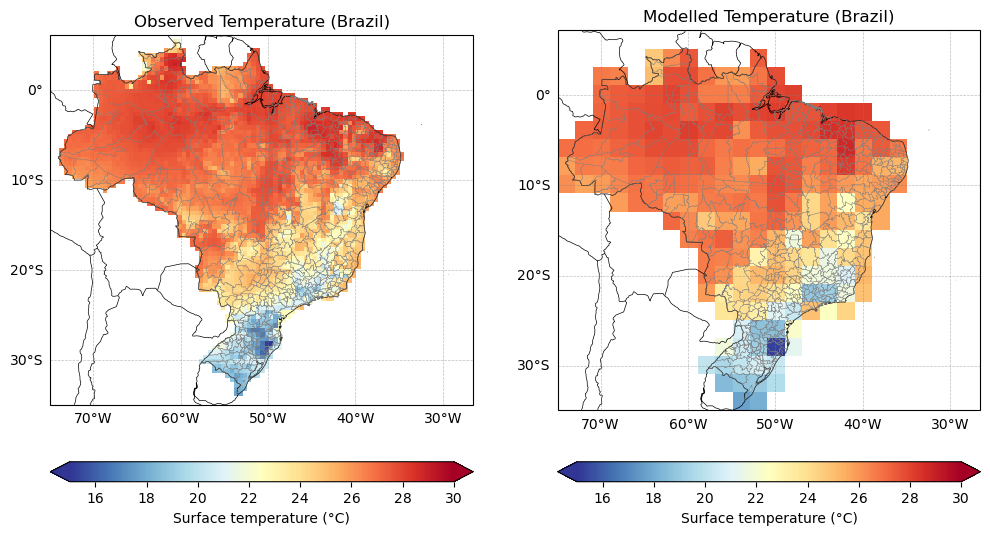

In [35]:
# Plot bias corrected model data
fig = plt.figure(figsize=(12, 6))
gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 0.05], hspace=0.2, wspace=0.2)

ax1 = fig.add_subplot(gs[0,0], projection=ccrs.PlateCarree())
im1 = obs_masked.mean(dim='time').plot(ax=ax1, cmap='RdYlBu_r', vmin=15, vmax=30, add_colorbar=False, transform=ccrs.PlateCarree(), zorder=1)
# Add shapefile boundaries 
shapefile.plot(ax=ax1, facecolor='none', edgecolor='grey', linewidth=0.2, transform=ccrs.PlateCarree(), zorder=2)
# Add features
ax1.add_feature(cfeature.BORDERS, linewidth=0.5)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax1.set_title("Observed Temperature (Brazil)")
# Add gridlines
gl = ax1.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax2 = fig.add_subplot(gs[0,1], projection=ccrs.PlateCarree())
im2 = tas_bc_masked.mean(dim='time').plot(ax=ax2, cmap='RdYlBu_r', vmin=15, vmax=30, add_colorbar=False, transform=ccrs.PlateCarree(), zorder=1)
# Add shapefile boundaries 
shapefile.plot(ax=ax2, facecolor='none', edgecolor='grey', linewidth=0.2, transform=ccrs.PlateCarree(), zorder=2)
# Add features
ax2.add_feature(cfeature.BORDERS, linewidth=0.5)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax2.set_title("Modelled Temperature (Brazil)")
# Add gridlines
gl = ax2.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cax1 = fig.add_subplot(gs[1, 0])
cbar1 = fig.colorbar(im1, cax=cax1, orientation='horizontal', extend='both')
cbar1.set_label("Surface temperature (°C)")

cax2 = fig.add_subplot(gs[1, 1])
cbar2 = fig.colorbar(im2, cax=cax2, orientation='horizontal', extend='both')
cbar2.set_label("Surface temperature (°C)")

#### 7. Downscale

In [36]:
bias_trim, obs_trim = af.prepare_bias_corrected_and_obs(tas_bias_corrected, obs)

Downscaling factor for lat: 4
Do actual and expected match? False
Max absolute difference: 0.25
Downscaling factor for lon: 4
Do actual and expected match? False
Max absolute difference: 0.25


In [37]:
# Replace nan with zeros
obs_trim = obs_trim.fillna(0)

In [38]:
# Extract arrays
obs_trim_arrays = [obs_trim.values]
bias_trim_arrays = [bias_trim.values]

In [39]:
# Run downscaling
sim_downscaled = dsf.main(
    obs_trim_arrays, bias_trim_arrays,
    variable=['tas'],
    years=years, days=days, month_numbers=month_numbers,
)

preparing downscaling ...
downscaling with fine resolution shape (84x84) ...


In [40]:
# Convert downscaled array back to xarray DataArray
tas_downscaled = xr.DataArray(
    sim_downscaled[0],  # Take the array from the list
    dims=obs_trim.dims,  # Same dimensions as original
    coords=obs_trim.coords,  # Same coordinates as original
    attrs=obs_trim.attrs,  # Same attributes as original
    name='tas'  # Same variable name
)

#### 8. Plot downscaled data 

In [41]:
# Apply land mask for plotting 
tas_downscaled_masked = tas_downscaled.isel(lat=slice(1,83)).isel(lon=slice(1,83))
tas_downscaled_masked = tas_downscaled_masked.assign_coords(lat=mask_05x05.lat, lon=mask_05x05.lon)
tas_downscaled_masked = tas_downscaled_masked.where(~np.isnan(mask_05x05))


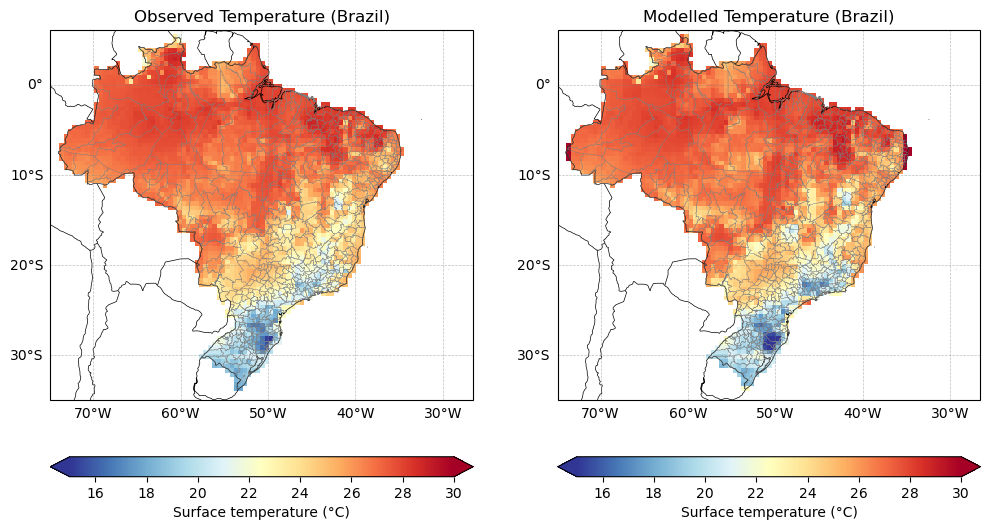

In [43]:
# Plot processed model data with obs to showcase bias 
fig = plt.figure(figsize=(12, 6))
gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 0.05], hspace=0.2, wspace=0.2)

ax1 = fig.add_subplot(gs[0,0], projection=ccrs.PlateCarree())
im1 = obs_masked.mean(dim='time').plot(ax=ax1, cmap='RdYlBu_r', vmin=15, vmax=30, add_colorbar=False, transform=ccrs.PlateCarree(), zorder=1)
# Add shapefile boundaries 
shapefile.plot(ax=ax1, facecolor='none', edgecolor='grey', linewidth=0.2, transform=ccrs.PlateCarree(), zorder=2)
# Add features
ax1.add_feature(cfeature.BORDERS, linewidth=0.5)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax1.set_title("Observed Temperature (Brazil)")
# Add gridlines
gl = ax1.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax2 = fig.add_subplot(gs[0,1], projection=ccrs.PlateCarree())
im2 = tas_downscaled_masked.mean(dim='time').plot(ax=ax2, cmap='RdYlBu_r', vmin=15, vmax=30, add_colorbar=False, transform=ccrs.PlateCarree(), zorder=1)
# Add shapefile boundaries 
shapefile.plot(ax=ax2, facecolor='none', edgecolor='grey', linewidth=0.2, transform=ccrs.PlateCarree(), zorder=2)
# Add features
ax2.add_feature(cfeature.BORDERS, linewidth=0.5)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax2.set_title("Modelled Temperature (Brazil)")
# Add gridlines
gl = ax2.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cax1 = fig.add_subplot(gs[1, 0])
cbar1 = fig.colorbar(im1, cax=cax1, orientation='horizontal', extend='both')
cbar1.set_label("Surface temperature (°C)")

cax2 = fig.add_subplot(gs[1, 1])
cbar2 = fig.colorbar(im2, cax=cax2, orientation='horizontal', extend='both')
cbar2.set_label("Surface temperature (°C)")

#### Questions for discussion 
1. What are the biggest challenges in using climate data at health-relevant scales?
2. What skills/knowledge do you wish you had when using climate data?
3. Are there any data outputs from BREATHE that would make your job easier?